# Title : Comparative Analysis of Deep Learning–Based Semantic Segmentation Models for Water Body Extraction from Remote Sensing Imagery

# Importing Libraries

In [1]:
# I imported the OS module to handle file paths and directory operations
import os

# I imported NumPy to perform numerical computations and array manipulations
import numpy as np

# I imported Matplotlib to visualize images, graphs, and model performance plots
import matplotlib.pyplot as plt

# I imported Seaborn to create enhanced statistical visualizations such as heatmaps and distributions
import seaborn as sns

# I imported TensorFlow to build, train, and evaluate the deep learning model
import tensorflow as tf

# I imported train_test_split to divide the dataset into training and testing subsets
from sklearn.model_selection import train_test_split

# I imported image loading utilities to read and convert images into arrays for model input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# I imported ImageDataGenerator to perform real-time data augmentation during model training
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# I imported kagglehub to download and access datasets directly from Kaggle within the notebook
import kagglehub

# Downloading the dataset

In [2]:
# I downloaded the water body satellite image dataset directly from Kaggle using kagglehub
path = kagglehub.dataset_download(
    "franciscoescobar/satellite-images-of-water-bodies"
)

# I printed the local directory path to confirm where the dataset was stored
print("Dataset downloaded to:", path)

100%|██████████| 247M/247M [00:09<00:00, 28.0MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/franciscoescobar/satellite-images-of-water-bodies/versions/2


# Loading the dataset

In [3]:
# I defined the dataset directory paths for images and corresponding segmentation masks
image_folder = f"{path}/Water Bodies Dataset/Images"
mask_folder  = f"{path}/Water Bodies Dataset/Masks"

# I created a function to load images and masks from the dataset folders and resize them
def load_images_from_folder(img_folder, mask_folder, img_size=(256, 256)):
    images, masks = [], []

    # I iterated through each image filename in the dataset
    for filename in os.listdir(img_folder):
        img_path  = os.path.join(img_folder, filename)
        mask_path = os.path.join(mask_folder, filename)

        # I ensured both image and corresponding mask existed before processing
        if os.path.exists(img_path) and os.path.exists(mask_path):

            # I loaded and resized the RGB satellite image
            img  = load_img(img_path,  target_size=img_size)

            # I loaded and resized the mask image in grayscale format
            mask = load_img(mask_path, target_size=img_size, color_mode="grayscale")

            # I converted images to arrays and normalized pixel values between 0 and 1
            img  = img_to_array(img) / 255.0
            mask = img_to_array(mask) / 255.0

            # I converted the mask into binary format (water = 1, background = 0)
            mask = (mask > 0.5).astype(np.float32)

            # I appended processed image and mask to their respective lists
            images.append(img)
            masks.append(mask)

    # I converted the lists into NumPy arrays for model training
    return np.array(images), np.array(masks)

# I loaded the full dataset using the defined function
X, y = load_images_from_folder(image_folder, mask_folder)

# I printed dataset shapes to verify successful loading and preprocessing
print("Images shape:", X.shape)
print("Masks shape:", y.shape)

Images shape: (2841, 256, 256, 3)
Masks shape: (2841, 256, 256, 1)


# Exploratory Data Analysis

Number of images: 2841
Image shape: (256, 256, 3)
Mask shape: (256, 256, 1)
Unique mask values: [0. 1.]


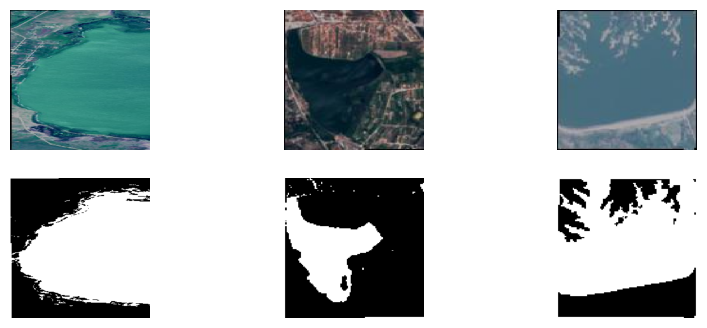

In [4]:
# I printed the total number of images available in the dataset
print("Number of images:", X.shape[0])

# I displayed the shape of each image (height, width, channels)
print("Image shape:", X.shape[1:])

# I displayed the shape of each segmentation mask
print("Mask shape:", y.shape[1:])

# I checked the unique values in masks to confirm they were binary (0 and 1)
print("Unique mask values:", np.unique(y))

# I created a figure to visualize sample images and their corresponding masks
plt.figure(figsize=(10,4))

# I plotted the first three images along with their masks
for i in range(3):

    # I displayed the original satellite image
    plt.subplot(2,3,i+1)
    plt.imshow(X[i])
    plt.axis("off")

    # I displayed the corresponding ground truth mask in grayscale
    plt.subplot(2,3,i+4)
    plt.imshow(y[i].squeeze(), cmap="gray")
    plt.axis("off")

# I rendered the visualization
plt.show()

# Splitting the dataset

In [5]:
# I split the dataset into training and testing sets using an 80–20 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# I further divided the training data to create a validation set (10% of the training data)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

# I printed the shapes of each dataset to verify the splitting process
print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (2044, 256, 256, 3)
Val:   (228, 256, 256, 3)
Test:  (569, 256, 256, 3)


# Data Augmentation

In [6]:
# I defined the batch size and fixed the random seed for reproducibility
BATCH_SIZE = 8
seed = 42

# I created augmentation settings to artificially expand the training dataset
data_gen_args = dict(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

# I initialized separate data generators for images and masks using the same augmentation parameters
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen  = ImageDataGenerator(**data_gen_args)

# I fitted the generators to the training data so that transformations remained consistent
image_datagen.fit(X_train, seed=seed)
mask_datagen.fit(y_train, seed=seed)

# I created a custom generator that yielded augmented image–mask pairs during training
def train_generator(batch_size=BATCH_SIZE, seed=seed):
    img_gen  = image_datagen.flow(X_train, batch_size=batch_size, seed=seed)
    mask_gen = mask_datagen.flow(y_train, batch_size=batch_size, seed=seed)
    while True:
        yield next(img_gen), next(mask_gen)

# I prepared the validation generator without augmentation and disabled shuffling
val_gen = ImageDataGenerator().flow(
    X_val, y_val, batch_size=BATCH_SIZE, shuffle=False
)

# SEGMENTATION METRICS (IoU & Dice)

In [7]:
# I defined the Intersection over Union (IoU) metric to measure overlap between predicted and true masks
def iou_metric(y_true, y_pred, smooth=1e-7):
    # I converted predicted probabilities into binary values using a threshold of 0.5
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    # I calculated the intersection and union areas
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    # I returned the IoU score with smoothing to avoid division by zero
    return (intersection + smooth) / (union + smooth)


# I implemented the Dice coefficient to evaluate segmentation similarity
def dice_coef(y_true, y_pred, smooth=1e-7):
    # I binarized the predictions
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    # I computed the overlap between ground truth and prediction
    intersection = tf.reduce_sum(y_true * y_pred)

    # I calculated the Dice score
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )


# I implemented the F1-score metric for segmentation performance evaluation
def f1_score(y_true, y_pred, smooth=1e-7):
    # I converted predictions to binary masks
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    # I calculated true positives, false positives, and false negatives
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    # I returned the F1 score with smoothing to prevent division errors
    return (2 * tp + smooth) / (2 * tp + fp + fn + smooth)

# LOSS FUNCTION (BCE + DICE)

In [8]:
def dice_loss(y_true, y_pred):
    # I defined the Dice loss function to measure the overlap between the predicted segmentation and the true mask.
    # I calculated it as (1 - Dice coefficient) so that minimizing the loss would maximize the similarity.
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    # I combined Binary Cross-Entropy (BCE) with Dice loss to improve segmentation performance.
    # I used BCE to measure pixel-wise classification error between the true labels and predictions.
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    # I added Dice loss to ensure better overlap between the predicted mask and the ground truth mask.
    # This helped balance both pixel accuracy and region similarity during model training.
    return bce + dice_loss(y_true, y_pred)

# COMPILE FUNCTION & CALLBACKS

In [9]:
def compile_model(model, lr=1e-4):
    # I created this function to compile the model with the required optimizer, loss function, and evaluation metrics.

    model.compile(
        # I used the Adam optimizer because it provides efficient and adaptive learning during training.
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),

        # I used the combined Binary Cross Entropy and Dice loss to improve segmentation performance.
        loss=bce_dice_loss,

        # I included multiple metrics to evaluate the model performance from different perspectives.
        # Accuracy measured pixel-wise correctness, IoU measured region overlap,
        # Dice coefficient measured segmentation similarity, and F1-score evaluated balance between precision and recall.
        metrics=["accuracy", iou_metric, dice_coef, f1_score]
    )

    # I returned the compiled model so it could be used for training.
    return model


# I set the number of training epochs to 20 so that the model could learn sufficiently from the data.
EPOCHS = 20

# I calculated the number of steps per epoch based on the size of the training dataset and batch size.
STEPS_PER_EPOCH = len(X_train) // BATCH_SIZE

# I calculated the number of validation steps using the validation dataset size.
VAL_STEPS = len(X_val) // BATCH_SIZE


# I implemented EarlyStopping to prevent overfitting during training.
early_stop = tf.keras.callbacks.EarlyStopping(

    # I monitored the validation IoU metric because it reflects segmentation performance.
    monitor="val_iou_metric",

    # I set the mode to "max" since higher IoU values indicate better performance.
    mode="max",

    # I allowed the model to continue training for 7 epochs without improvement before stopping.
    patience=7,

    # I restored the best model weights obtained during training.
    restore_best_weights=True
)

# MODEL ARCHITECTURES (DEFINED ONCE)

# Simple U-Net (Baseline Semantic Segmentation)

In [10]:
from tensorflow.keras import layers, Model

def simple_unet(input_shape=(256, 256, 3)):

    # I defined the input layer to accept images of size 256x256 with 3 color channels (RGB).
    inputs = layers.Input(input_shape)


    # Encoder (Downsampling Path)
    # I applied a convolution layer with 16 filters to extract basic spatial features from the input image.
    c1 = layers.Conv2D(16, 3, activation="relu", padding="same")(inputs)

    # I used a MaxPooling layer to reduce the spatial dimensions and capture more abstract features.
    p1 = layers.MaxPooling2D()(c1)

    # I added another convolution layer with 32 filters to learn deeper and more complex feature representations.
    c2 = layers.Conv2D(32, 3, activation="relu", padding="same")(p1)

    # I again applied MaxPooling to further reduce the feature map size while increasing receptive field.
    p2 = layers.MaxPooling2D()(c2)


    # Bottleneck
    # I implemented the bottleneck layer with 64 filters to capture the most compressed and high-level features.
    b = layers.Conv2D(64, 3, activation="relu", padding="same")(p2)


    # Decoder (Upsampling Path)
    # I used UpSampling to increase the spatial resolution of the feature maps.
    u2 = layers.UpSampling2D()(b)

    # I concatenated the upsampled features with the corresponding encoder features (skip connection) to preserve spatial information.
    u2 = layers.Concatenate()([u2, c2])

    # I applied another convolution layer to refine the combined features.
    c3 = layers.Conv2D(32, 3, activation="relu", padding="same")(u2)

    # I again performed upsampling to restore the feature maps closer to the original input resolution.
    u1 = layers.UpSampling2D()(c3)

    # I concatenated these features with the earlier encoder layer to maintain fine-grained spatial details.
    u1 = layers.Concatenate()([u1, c1])

    # I applied a convolution layer with 16 filters to further refine the reconstructed features.
    c4 = layers.Conv2D(16, 3, activation="relu", padding="same")(u1)


    # Output Layer
    # I used a 1x1 convolution with sigmoid activation to generate the final segmentation mask.
    # This layer produced a single-channel output representing the probability of each pixel belonging to the target class.
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c4)

    # I created and returned the U-Net model.
    return Model(inputs, outputs, name="Simple_UNet")